# Boundary Value Problems for ODEs

examples

In [86]:
import numpy as np
from fractions import Fraction
from functools import reduce, lru_cache, partial

from scipy import linalg as la
import scipy.optimize as opt
from scipy import special, interpolate, integrate
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
np.set_printoptions(suppress=True, precision=6)

def sign(x):
    s = np.sign(x)
    return s if s else 1

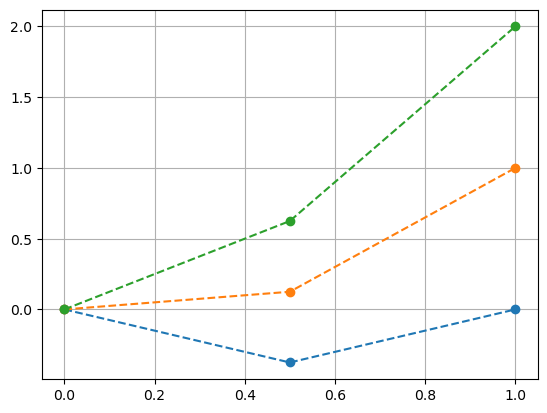

In [87]:
# 10.6
def f(t, y):
    return [y[1], 6 * t]

for n in range(-1, 2, 1):
    sol = integrate.solve_ivp(f, t_span=[0, 1], t_eval=[0, .5, 1], y0=[0, n])
    plt.plot(sol.t, sol.y[0], 'o--')
plt.grid(True)

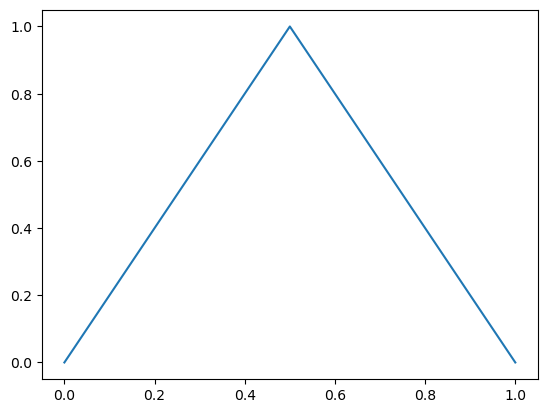

In [88]:
import numpy as np
from scipy.interpolate import BSpline

# 内部节点 [1, 2, 3]，推断次数为3
b = BSpline.basis_element([0, .5, 1])
# 此时 b 已变成一个可调用对象，代表这个基函数

# 在区间上用较密的点进行计算
x_plot = np.linspace(0, 1, 101)
y_plot = b(x_plot)
plt.plot(x_plot, y_plot)

computer problems

In [89]:
# 10.1
# (a)
def f(t, y):
    return 10 * y ** 3 + 3 * y + t ** 2


def new_f(t, x):
    return [x[1], f(t, x[0])]

def g(x):
    return integrate.solve_ivp(new_f, t_span=[0, 1], y0=[0, x]).y[0][-1] - 1


s_shoot = opt.root_scalar(g, x0=0).root

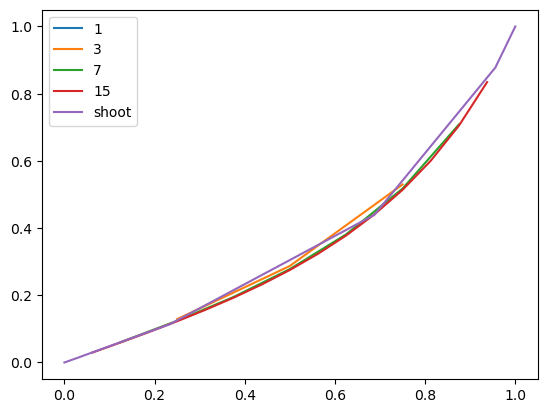

In [90]:
# (b)
def h(y, n):
    zs = []
    h = 1 / (n + 1)
    for i in range(n):
        t = (i + 1) * h
        z = -2 * y[i] - h ** 2 * f(t, y[i])
        if i > 0:
            z += y[i-1]
        if i < n - 1:
            z += y[i+1]
        else:
            z += 1
        zs.append(z)
    return zs


def generate_x0(n):
    return np.arange(1, n+1) / (n+1)

for n in 1, 3, 7, 15:
    y = opt.root(partial(h, n=n), x0=generate_x0(n)).x
    plt.plot(np.arange(1, n+1) / (n+1), y, label=n)

sol = integrate.solve_ivp(new_f, t_span=[0, 1], y0=[0, s_shoot])
plt.plot(sol.t, sol.y[0], label='shoot')
plt.legend()

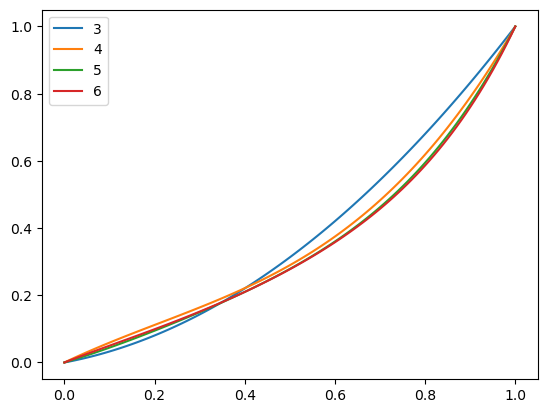

In [91]:
# (c)
def monomial_bases(nodes):
    return [Polynomial([0] * n + [1]) for n in range(len(nodes))]


for n in 3, 4, 5, 6:
    def cf(xs, n):
        ps = monomial_bases(np.arange(n))
        sp = sum([x * p for x, p in zip(xs, ps)])
        p2s = [p.deriv(2) for p in ps]
        sp2 = sum([x * p for x, p in zip(xs, p2s)])

        zs = [sp(0)]
        h = 1 / (n - 1)
        for i in range(1, n - 1):
            t = i * h
            zs.append(sp2(t) - f(t, sp(t)))
        zs.append(sp(1) - 1)
        return zs

    xs = opt.root(partial(cf, n=n), x0=np.concatenate([[0], generate_x0(n-2), [1]])).x
    ps = monomial_bases(np.arange(n))
    sp = sum([x * p for x, p in zip(xs, ps)])
    plt.plot(np.linspace(0, 1, 101), sp(np.linspace(0, 1, 101)), label=n)

plt.legend()

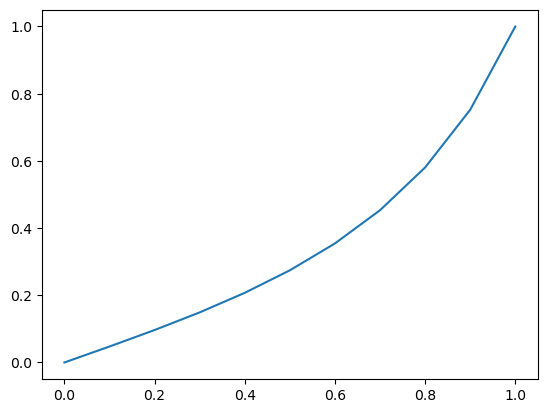

In [92]:
def bc(ya, yb):
    return [ya[0], yb[0] - 1]

n = 11
x = np.linspace(0, 1, n)
y_init = np.vstack([
    np.linspace(0, 1, n) / (n - 1),
    np.ones(n),
])
sol = integrate.solve_bvp(new_f, bc=bc, x=x, y=y_init)

plt.plot(x, sol.sol(x)[0])

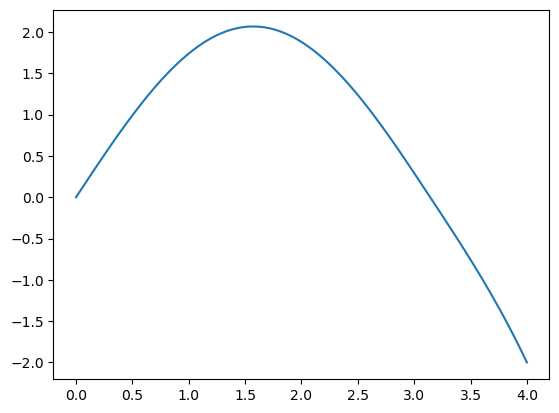

In [107]:
# 10.3
def f(t, y):
    return [y[1], - np.abs(y[0])]


def bc(ya, yb):
    return [ya[0], yb[0] + 2]


x = np.linspace(0, 4, 11)
y_init = np.zeros((2, 11))

sol = integrate.solve_bvp(f, bc=bc, x=x, y=y_init)

plt.plot(np.linspace(0, 4, 101), sol.sol(np.linspace(0, 4, 101))[0])

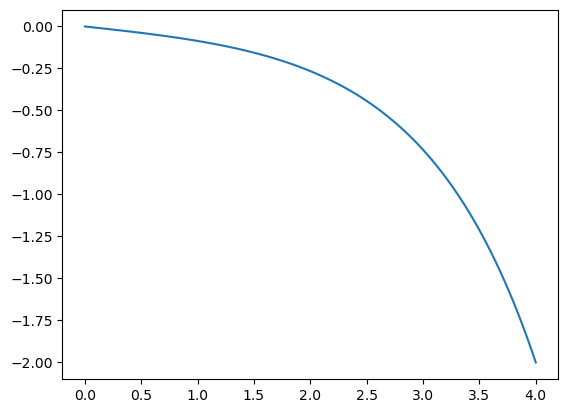

In [109]:
x = np.linspace(0, 4, 11)
y_init = - np.ones((2, 11))

sol = integrate.solve_bvp(f, bc=bc, x=x, y=y_init)

plt.plot(np.linspace(0, 4, 101), sol.sol(np.linspace(0, 4, 101))[0])

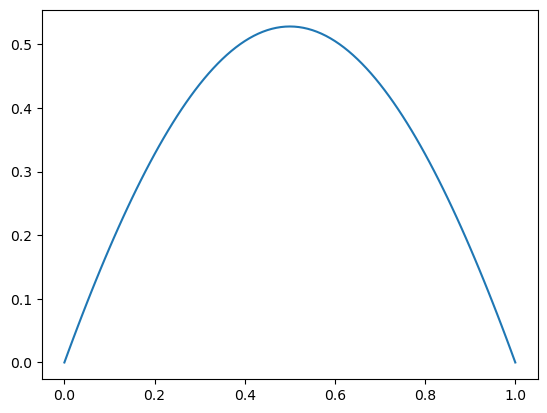

In [96]:
# 10.4
def f(t, y):
    return [y[1], - np.exp(y[0] + 1)]


def bc(ya, yb):
    return [ya[0], yb[0]]


x = np.linspace(0, 1, 11)
y_init = np.zeros((2, 11))

sol = integrate.solve_bvp(f, bc=bc, x=x, y=y_init)

plt.plot(np.linspace(0, 1, 101), sol.sol(np.linspace(0, 1, 101))[0])

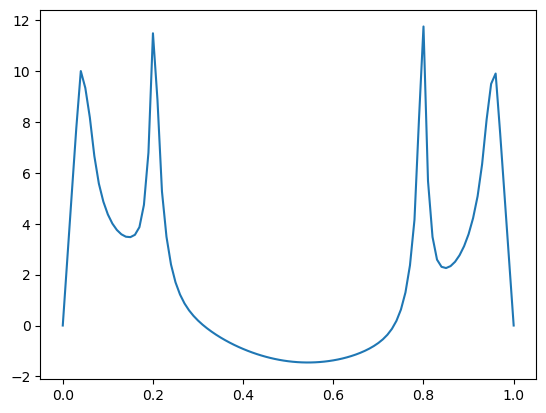

In [ ]:
x = np.linspace(0, 1, 11)

y_init = np.ones((2, 11)) * 4
sol = integrate.solve_bvp(f, bc=bc, x=x, y=y_init)

plt.plot(np.linspace(0, 1, 101), sol.sol(np.linspace(0, 1, 101))[0])

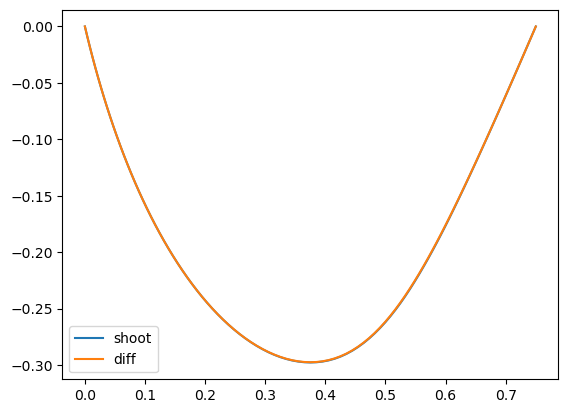

In [140]:
# 10.5
def f(t, y):
    return [
        np.cos(y[2]),
        np.sin(y[2]),
        (np.cos(y[2]) - np.sin(y[2]) * np.abs(np.sin(y[2]))) / y[3],
        np.sin(y[2]) - np.cos(y[2]) * np.abs(np.cos(y[2])),
    ]


def g(y, y12):
    return integrate.solve_ivp(f, t_span=[0, 1], y0=np.concatenate([[0, 0], y])).y[:, -1][:2] - y12

n = 100
x = np.linspace(0, 1, n)

y34 = opt.root(partial(g, y12=[.75, 0]), x0=[0, 1]).x
shoot_sol = integrate.solve_ivp(f, t_span=[0, 1], y0=np.concatenate([[0, 0], y34]), t_eval=x)
plt.plot(shoot_sol.y[0], shoot_sol.y[1], label='shoot')

def bc(ya, yb):
    return [ya[0], ya[1], yb[0] - .75, yb[1]]

sol = integrate.solve_bvp(f, bc=bc, x=x, y=shoot_sol.y)
plt.plot(sol.y[0], sol.y[1], label='diff')
plt.legend()

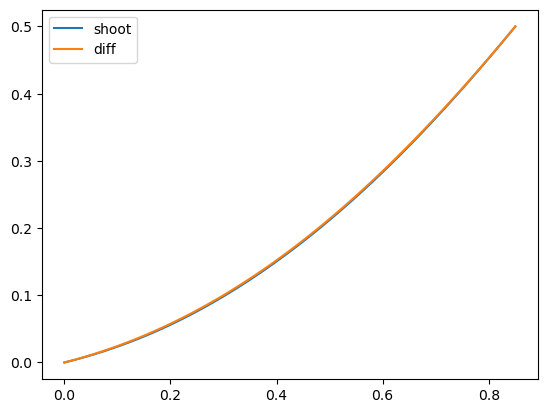

In [143]:
y34 = opt.root(partial(g, y12=[.85, 0.5]), x0=[0, 1]).x
shoot_sol = integrate.solve_ivp(f, t_span=[0, 1], y0=np.concatenate([[0, 0], y34]), t_eval=x)
plt.plot(shoot_sol.y[0], shoot_sol.y[1], label='shoot')

def bc(ya, yb):
    return [ya[0], ya[1], yb[0] - .85, yb[1] - .5]


sol = integrate.solve_bvp(f, bc=bc, x=x, y=shoot_sol.y)
plt.plot(sol.y[0], sol.y[1], label='diff')
plt.legend()

In [154]:
# 10.6
def generate_a(n):
    h = 1 / (n + 1)
    A = (np.eye(n) * (-2) + np.diag(np.ones(n-1), 1) + np.diag(np.ones(n-1), -1)) / h ** 2
    for i in range(n):
        t = (i + 1) * h
        A[i] /= - t ** 2 - 1
    return A


for n in range(3, 10):
    print(sorted(la.eigvals(generate_a(n))))

[np.complex128(7.256493090755038+0j), np.complex128(24.46020987008273+0j), np.complex128(44.48094409798577+0j)]
[np.complex128(7.391315662784247+0j), np.complex128(26.30758415551047+0j), np.complex128(49.84970505524936+0j), np.complex128(74.8842772396427+0j)]
[np.complex128(7.4666516162524195+0j), np.complex128(27.41848566705196+0j), np.complex128(54.45396056674355+0j), np.complex128(82.37277267704421+0j), np.complex128(113.08014065180416+0j)]
[np.complex128(7.512746370020944+0j), np.complex128(28.11680412715618+0j), np.complex128(57.666330464028256+0j), np.complex128(90.19398543110479+0j), np.complex128(122.02229281404357+0j), np.complex128(159.18765044270154+0j)]
[np.complex128(7.542923957975465+0j), np.complex128(28.580259564194332+0j), np.complex128(59.873896282496275+0j), np.complex128(96.41818397047285+0j), np.complex128(132.8523545038428+0j), np.complex128(169.05536379643368+0j), np.complex128(213.25807251430334+0j)]
[np.complex128(7.56372955317459+0j), np.complex128(28.90240520

[np.complex128(9.372583002030474+0j), np.complex128(32+0j), np.complex128(54.627416997969476+0j)]
[np.complex128(9.549150281252622+0j), np.complex128(34.54915028125268+0j), np.complex128(65.45084971874735+0j), np.complex128(90.45084971874735+0j)]
[np.complex128(9.646170927520416+0j), np.complex128(36.00000000000001+0j), np.complex128(72.00000000000006+0j), np.complex128(108+0j), np.complex128(134.35382907247939+0j)]
[np.complex128(9.705050945562917+0j), np.complex128(36.897999417844126+0j), np.complex128(76.19294847228117+0j), np.complex128(119.80705152771888+0j), np.complex128(159.10200058215594+0j), np.complex128(186.294949054437+0j)]
[np.complex128(9.743419838555322+0j), np.complex128(37.49033200812189+0j), np.complex128(79.0165206572685+0j), np.complex128(128.0000000000001+0j), np.complex128(176.98347934273144+0j), np.complex128(218.509667991878+0j), np.complex128(246.25658016144473+0j)]
[np.complex128(9.769795432682848+0j), np.complex128(37.90080021472552+0j), np.complex128(80.999

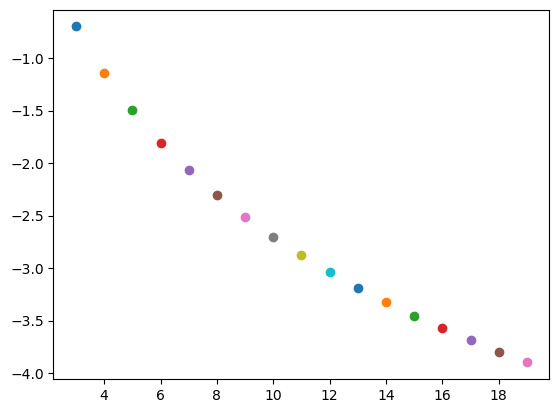

In [160]:
# 10.7
def generate_a(n):
    h = 1 / (n + 1)
    return - (np.eye(n) * (-2) + np.diag(np.ones(n-1), 1) + np.diag(np.ones(n-1), -1)) / h ** 2


for n in range(3, 20):
    eigs = sorted(la.eigvals(generate_a(n)))
    print(eigs)
    plt.scatter(n, np.log(np.abs(eigs[0] - np.pi ** 2)))
